# ResNET Evaluation

## Imports

In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))

import torch
from torch import nn
from torchvision import models
from src.data import createDataset, createDataLoader, test_transforms

torch.manual_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cuda


## Test Dataset and Dataloader

In [2]:
test_dataset = createDataset(
    path='../dataset/test',
    transform=test_transforms
)

test_dataloader = createDataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=True
)

## ResNET Frozen - Evaluation

In [3]:
frozen_model = models.resnet18(weights=None)

frozen_model.fc = nn.Linear(frozen_model.fc.in_features, 4)

frozen_model.load_state_dict(
    torch.load('../models/ResNET_Frozen.pt')
)

frozen_model = frozen_model.to(device)

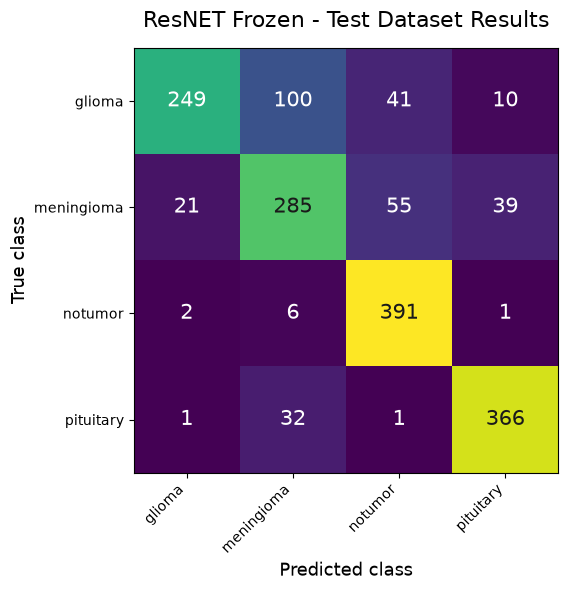

In [4]:
from src.evaluation import evaluateModel, plot_confusion_matrix

frozen_results, frozen_cm = evaluateModel(
    model=frozen_model,
    dataloader=test_dataloader,
    device=device
)

plot_confusion_matrix(frozen_cm, test_dataset.classes, "ResNET Frozen - Test Dataset Results")

## ResNET Frozen + PartialFT - Evaluation

In [5]:
partialFT_model = models.resnet18(weights=None)

partialFT_model.fc = nn.Linear(partialFT_model.fc.in_features, 4)

partialFT_model.load_state_dict(
    torch.load('../models/ResNET_Frozen_PartialFT.pt')
)

partialFT_model = partialFT_model.to(device)

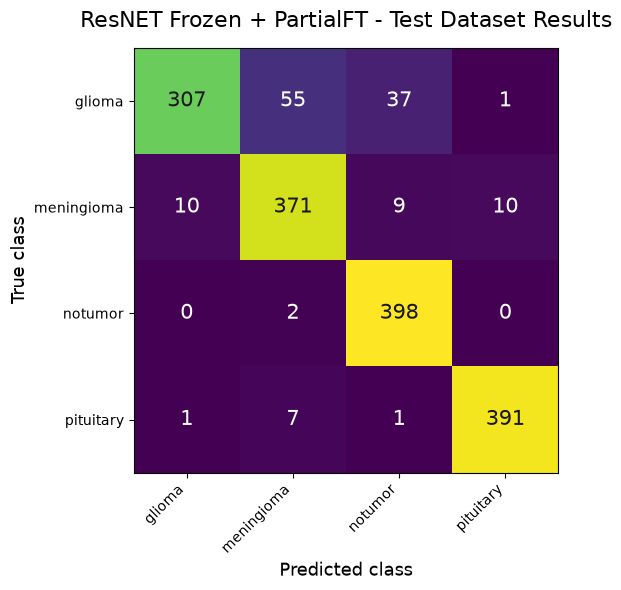

In [6]:
partialFT_results, partialFT_cm = evaluateModel(
    model=partialFT_model,
    dataloader=test_dataloader,
    device=device
)

plot_confusion_matrix(partialFT_cm, test_dataset.classes, "ResNET Frozen + PartialFT - Test Dataset Results")

## ResNET Frozen + CompleteFT - Evaluation

In [7]:
completeFT_model = models.resnet18(weights=None)

completeFT_model.fc = nn.Linear(completeFT_model.fc.in_features, 4)

completeFT_model.load_state_dict(
    torch.load('../models/ResNET_Frozen_FT.pt')
)

completeFT_model = completeFT_model.to(device)

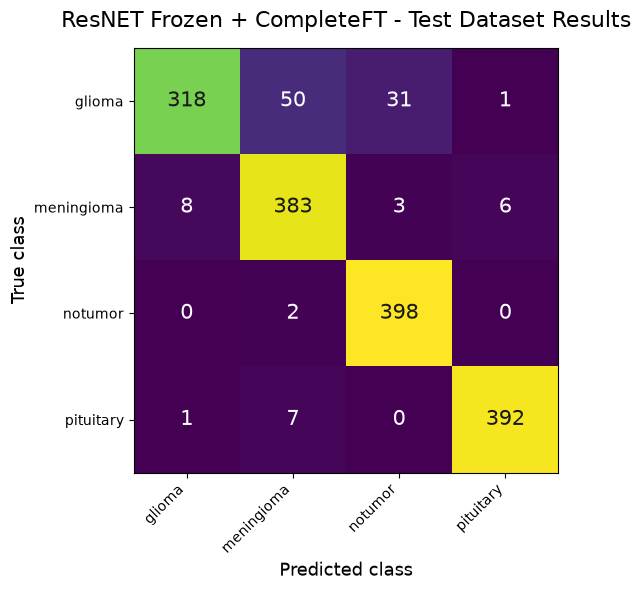

In [8]:
completeFT_results, completeFT_cm = evaluateModel(
    model=completeFT_model,
    dataloader=test_dataloader,
    device=device
)

plot_confusion_matrix(completeFT_cm, test_dataset.classes, "ResNET Frozen + CompleteFT - Test Dataset Results")